# ORIGEN — Paso 3: KPIs operativos

**Proyecto:** E-commerce Operations & Supply Chain Analytics · **Fuente:** los 6 CSV de `data/raw/`
(misma carga y criterio de alcance validados en `python/eda/01_eda.ipynb`).

**Principios de este notebook**

- Cada KPI responde una pregunta de negocio de `docs/00_contexto_y_alcance.md` §7 y está
  definido con fórmula explícita en **`docs/05_kpis.md`** (la tabla de definiciones vive
  allí; aquí se calculan los valores).
- Sin métricas inventadas para llenar un dashboard. **Sin métricas financieras** (no hay precios).
- Los KPIs principales se calculan sobre **Fase 4**; los movimientos conservan su triple
  clasificación (Fase 4 / heredado / Global sin pedido); `stock_historico` se analiza completo.
- **SLA:** no existe una meta SLA definida en el proyecto → **no se calcula cumplimiento SLA**;
  solo se conservan los tiempos operativos para análisis posterior.
- **No se crea `data/processed/`**: todos los resultados quedan en este notebook.

| # | Sección |
|---|---|
| 1 | Carga, alcance y validaciones |
| 2 | Tabla resumen de KPIs |
| 3 | Pedidos y cancelaciones |
| 4 | Incidencias |
| 5 | Inventario (stock y movimientos) |
| 6 | Devoluciones |
| 7 | Desgloses: fecha, tienda, canal, categoría |
| 8 | Campaña vs. no campaña |
| 9 | SLA (no definido) |
| 10 | Limitaciones |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
%matplotlib inline


def encontrar_raiz(inicio: Path) -> Path:
    """Localiza la raíz del repositorio buscando hacia arriba desde el directorio de trabajo."""
    for candidato in [inicio, *inicio.parents]:
        if (candidato / "data" / "raw").is_dir() and (candidato / "sql").is_dir():
            return candidato
    raise FileNotFoundError(f"No se encontró data/raw + sql partiendo de {inicio}")


RAIZ = encontrar_raiz(Path.cwd())
RAW = RAIZ / "data" / "raw"
print("Repositorio:", RAIZ.name)
print("Datos:", RAW.relative_to(RAIZ))

Repositorio: origen-ecommerce-analytics
Datos: data\raw


## 1. Carga, alcance y validaciones

Se leen los 6 CSV y se aplica el **mismo criterio de alcance validado en el EDA**:

| Dataset | Alcance de los KPIs |
|---|---|
| `pedidos_operaciones`, `tiempos_estados`, `devoluciones` | `PedidoID` 100001–100045 → **Fase 4**; 990001–990030 → heredado (excluido de los KPIs principales) |
| `incidencias` | `PedidoID` cuando existe; recepciones CD sin línea → por fecha de detección |
| `movimientos` | Fase 4 / heredado / **Global (sin pedido)** — los tres se reportan |
| `stock_historico` | **Completo** (no depende de `PedidoID`) |

In [2]:
ARCHIVOS = {
    "pedidos": "pedidos_operaciones.csv",
    "tiempos": "tiempos_estados.csv",
    "incidencias": "incidencias.csv",
    "movimientos": "movimientos.csv",
    "stock": "stock_historico.csv",
    "devoluciones": "devoluciones.csv",
}
datos = {n: pd.read_csv(RAW / f) for n, f in ARCHIVOS.items()}
p, t, i, m, s, d = (datos[k] for k in ["pedidos", "tiempos", "incidencias", "movimientos", "stock", "devoluciones"])

i["FechaHoraDeteccion"] = pd.to_datetime(i["FechaHoraDeteccion"])

F4_MIN, F4_MAX = 100001, 100045


def etiquetar_pedido(pid):
    if pd.isna(pid):
        return None
    return "Fase 4" if F4_MIN <= pid <= F4_MAX else "Heredado Fase 3"


p["Alcance"] = p["PedidoID"].map(etiquetar_pedido)
t["Alcance"] = t["PedidoID"].map(etiquetar_pedido)
d["Alcance"] = d["PedidoID"].map(etiquetar_pedido)
i["Alcance"] = i["PedidoID"].map(etiquetar_pedido)
sin_pedido = i["Alcance"].isna()
i.loc[sin_pedido, "Alcance"] = (
    i.loc[sin_pedido, "FechaHoraDeteccion"]
    .ge(pd.Timestamp("2026-10-01"))
    .map({True: "Fase 4", False: "Heredado Fase 3"})
)
m["Alcance"] = m["PedidoID"].map(etiquetar_pedido).fillna("Global (sin pedido)")

f4 = p[p["Alcance"] == "Fase 4"]
i4 = i[i["Alcance"] == "Fase 4"]
t4 = t[t["Alcance"] == "Fase 4"]

print("Registros por alcance (igual que en el EDA):")
print(pd.concat({
    "líneas": p["Alcance"], "episodios": t["Alcance"], "incidencias": i["Alcance"],
    "movimientos": m["Alcance"], "devoluciones": d["Alcance"],
}).value_counts().to_string())
print("\nstock_historico: alcance no aplica —", len(s), "filas completas.")

Registros por alcance (igual que en el EDA):
Alcance
Fase 4                 443
Heredado Fase 3         42
Global (sin pedido)     22

stock_historico: alcance no aplica — 5040 filas completas.


In [3]:
# Validaciones: si algo no cuadra, el notebook se detiene (no se ocultan diferencias).
cierre = s[s["FechaID"] == s["FechaID"].max()]
negativos = int((s[["StockSistema", "StockReservado", "StockDisponible"]] < 0).sum().sum())
ef = f4["EstadoActual"].value_counts()
orden_estados = ["Completado", "Cancelado", "Rechazado", "Incidencia de picking", "Disponible para recojo"]
sis_mov = int(m.loc[m["TipoMovimiento"].isin(["INGRESO", "AJUSTE", "DESCUENTO_DEFINITIVO"]), "Cantidad"].sum())
res_mov = int(m.loc[m["TipoMovimiento"].isin(["RESERVA", "LIBERACION_RESERVA", "DESCUENTO_DEFINITIVO"]), "Cantidad"].sum())

chequeos = [
    ("45 pedidos Fase 4", int(f4["PedidoID"].nunique()), 45),
    ("52 líneas Fase 4", len(f4), 52),
    ("11 incidencias Fase 4", len(i4), 11),
    ("6 devoluciones", len(d), 6),
    ("0 celdas de stock negativas", negativos, 0),
    ("116 movimientos en el ledger", len(m), 116),
    ("47 StockSistema al cierre", int(cierre["StockSistema"].sum()), 47),
    ("45 StockDisponible al cierre", int(cierre["StockDisponible"].sum()), 45),
    ("estados F4 = 31/11/8/2/0", [int(ef.get(e, 0)) for e in orden_estados], [31, 11, 8, 2, 0]),
    ("ledger reconstruye StockSistema (47)", sis_mov, int(cierre["StockSistema"].sum())),
    ("ledger reconstruye StockReservado (2)", res_mov, int(cierre["StockReservado"].sum())),
]
for nombre, obtenido, esperado in chequeos:
    print(f"[{'OK' if obtenido == esperado else 'FALLA'}] {nombre}: obtenido={obtenido} esperado={esperado}")

fallos = [(n, o, e) for n, o, e in chequeos if o != e]
if fallos:
    raise AssertionError(f"Validación fallida — diagnosticar antes de continuar: {fallos}")
print("\nValidaciones: 11/11 OK")

[OK] 45 pedidos Fase 4: obtenido=45 esperado=45
[OK] 52 líneas Fase 4: obtenido=52 esperado=52
[OK] 11 incidencias Fase 4: obtenido=11 esperado=11
[OK] 6 devoluciones: obtenido=6 esperado=6
[OK] 0 celdas de stock negativas: obtenido=0 esperado=0
[OK] 116 movimientos en el ledger: obtenido=116 esperado=116
[OK] 47 StockSistema al cierre: obtenido=47 esperado=47
[OK] 45 StockDisponible al cierre: obtenido=45 esperado=45
[OK] estados F4 = 31/11/8/2/0: obtenido=[31, 11, 8, 2, 0] esperado=[31, 11, 8, 2, 0]
[OK] ledger reconstruye StockSistema (47): obtenido=47 esperado=47
[OK] ledger reconstruye StockReservado (2): obtenido=2 esperado=2

Validaciones: 11/11 OK


## 2. Tabla resumen de KPIs

Los 11 KPIs base con su valor de la Fase 4. Cada fila se deriva en detalle en las secciones
siguientes; las definiciones completas (definición, fórmula, unidad, fuente, alcance,
desglose, interpretación y limitaciones) están en `docs/05_kpis.md`.

In [4]:
# --- KPIs 1 a 11 (todas las cifras salen de los CSV, ninguna está escrita a mano) ---
n_pedidos = int(f4["PedidoID"].nunique())
n_lineas = len(f4)

canceladas = f4["EstadoActual"].eq("Cancelado")
n_canceladas = int(canceladas.sum())
kpi_cancel_lineas = 100 * n_canceladas / n_lineas
ped_con_cancel = int(f4.loc[canceladas, "PedidoID"].nunique())
kpi_cancel_pedidos = 100 * ped_con_cancel / n_pedidos

n_mot_inc = int((canceladas & f4["MotivoCancelacion"].eq("incidencia_picking")).sum())
kpi_cancel_incidencia = 100 * n_mot_inc / n_canceladas

canal = f4["Canal"].value_counts()
kpi_canal = {k: 100 * v / n_lineas for k, v in canal.items()}

kpi_inc100 = 100 * len(i4) / n_lineas
no_resueltas = int(i4["EstadoResolucion"].ne("resuelta").sum())
kpi_no_res = 100 * no_resueltas / len(i4)
tipos = i4["TipoIncidencia"].value_counts()
tipos_txt = " · ".join(f"{k} {100 * v / len(i4):.1f}%" for k, v in tipos.items())

sis_cierre = int(cierre["StockSistema"].sum())
res_cierre = int(cierre["StockReservado"].sum())
disp_cierre = int(cierre["StockDisponible"].sum())
combos_cero = int(cierre["StockDisponible"].eq(0).sum())
kpi_stock0_pct = 100 * combos_cero / len(cierre)

mv_alcance = m["Alcance"].value_counts()
txt_mov = f"{len(m)} totales (Fase 4 {mv_alcance.get('Fase 4', 0)} · heredado {mv_alcance.get('Heredado Fase 3', 0)} · global {mv_alcance.get('Global (sin pedido)', 0)})"

entregadas = int(f4["EstadoActual"].eq("Completado").sum())
kpi_tasa_dev = 100 * len(d) / entregadas

kpis = pd.DataFrame([
    {"#": 1, "KPI": "Pedidos gestionados", "valor": f"{n_pedidos} pedidos ({n_lineas} líneas, {int(f4['Cantidad'].sum())} unidades)", "unidad": "pedidos", "alcance": "Fase 4"},
    {"#": 2, "KPI": "% de cancelación (líneas)", "valor": f"{kpi_cancel_lineas:.1f}%", "unidad": "%", "alcance": "Fase 4"},
    {"#": 3, "KPI": "% de cancelación por incidencia", "valor": f"{kpi_cancel_incidencia:.1f}%", "unidad": "%", "alcance": "Fase 4"},
    {"#": 4, "KPI": "Distribución por canal", "valor": " · ".join(f"{k} {v:.1f}%" for k, v in kpi_canal.items()), "unidad": "%", "alcance": "Fase 4"},
    {"#": 5, "KPI": "Incidencias por 100 líneas", "valor": f"{kpi_inc100:.1f}", "unidad": "inc./100 líneas", "alcance": "Fase 4"},
    {"#": 6, "KPI": "% de incidencias no resueltas", "valor": f"{kpi_no_res:.1f}% ({no_resueltas} de {len(i4)})", "unidad": "%", "alcance": "Fase 4"},
    {"#": 7, "KPI": "Incidencias por tipo/motivo", "valor": tipos_txt, "unidad": "%", "alcance": "Fase 4"},
    {"#": 8, "KPI": "Stock disponible al cierre", "valor": f"{disp_cierre} u. (sistema {sis_cierre} · reservado {res_cierre})", "unidad": "unidades", "alcance": "completo"},
    {"#": 9, "KPI": "SKUs/tiendas con stock = 0", "valor": f"{combos_cero} de {len(cierre)} combos ({kpi_stock0_pct:.1f}%)", "unidad": "combos y %", "alcance": "completo"},
    {"#": 10, "KPI": "Movimientos de inventario", "valor": txt_mov, "unidad": "movimientos", "alcance": "los tres"},
    {"#": 11, "KPI": "Tasa de devolución", "valor": f"{kpi_tasa_dev:.1f}% ({len(d)} de {entregadas} líneas completadas)", "unidad": "%", "alcance": "Fase 4"},
])
display(kpis)

,#,KPI,valor,unidad,alcance
0,1,Pedidos gestionados,"45 pedidos (52 líneas, 87 unidades)",pedidos,Fase 4
1,2,% de cancelación (líneas),21.2%,%,Fase 4
2,3,% de cancelación por incidencia,27.3%,%,Fase 4
3,4,Distribución por canal,recojo 59.6% · despacho 40.4%,%,Fase 4
4,5,Incidencias por 100 líneas,21.2,inc./100 líneas,Fase 4
5,6,% de incidencias no resueltas,54.5% (6 de 11),%,Fase 4
6,7,Incidencias por tipo/motivo,no_encontrado 36.4% · cantidad_insuficiente 27...,%,Fase 4
7,8,Stock disponible al cierre,45 u. (sistema 47 · reservado 2),unidades,completo
8,9,SKUs/tiendas con stock = 0,44 de 56 combos (78.6%),combos y %,completo
9,10,Movimientos de inventario,116 totales (Fase 4 86 · heredado 8 · global 22),movimientos,los tres


## 3. Pedidos y cancelaciones

```
% cancelación (líneas)          = líneas con EstadoActual = "Cancelado" / líneas Fase 4 × 100
% cancelación por incidencia    = canceladas con motivo "incidencia_picking" / canceladas × 100
```

El estado (`EstadoActual`) es atributo de **línea**, y tienda/categoría/canal también viven a
nivel de línea, por eso el KPI principal se mide sobre líneas. Las variantes a nivel de pedido
se muestran aparte para no esconder la diferencia de grano.

In [5]:
variante = pd.DataFrame([
    {"nivel": "línea (principal)", "numerador": n_canceladas, "denominador": n_lineas, "resultado %": round(kpi_cancel_lineas, 1)},
    {"nivel": "pedido con ≥1 línea cancelada", "numerador": ped_con_cancel, "denominador": n_pedidos, "resultado %": round(kpi_cancel_pedidos, 1)},
    {"nivel": "pedido con TODAS sus líneas canceladas", "numerador": int((f4.assign(c=canceladas).groupby("PedidoID")["c"].all()).sum()), "denominador": n_pedidos, "resultado %": round(100 * int((f4.assign(c=canceladas).groupby("PedidoID")["c"].all()).sum()) / n_pedidos, 1)},
])
display(variante)

print(f"Canceladas por motivo de incidencia: {n_mot_inc} de {n_canceladas} = {kpi_cancel_incidencia:.1f}%",
      f"(sobre líneas gestionadas sería {100 * n_mot_inc / n_lineas:.1f}%)")
display(f4.loc[canceladas, "MotivoCancelacion"].value_counts().rename("líneas canceladas").to_frame())

,nivel,numerador,denominador,resultado %
0,línea (principal),11,52,21.2
1,pedido con ≥1 línea cancelada,11,45,24.4
2,pedido con TODAS sus líneas canceladas,8,45,17.8


Canceladas por motivo de incidencia: 3 de 11 = 27.3% (sobre líneas gestionadas sería 5.8%)


,líneas canceladas
MotivoCancelacion,
voluntaria,6
incidencia_picking,3
vencimiento,2


## 4. Incidencias

```
Incidencias por 100 líneas   = incidencias Fase 4 / líneas Fase 4 × 100
% no resueltas               = incidencias con EstadoResolucion ≠ "resuelta" / incidencias Fase 4 × 100
Por tipo/motivo              = conteo por TipoIncidencia / incidencias Fase 4 × 100
```

"No resuelta" agrupa `no_resuelta`, `en_atencion` y `escalada` (ninguna cerró como `resuelta`).

In [6]:
print(f"Incidencias por 100 líneas: {kpi_inc100:.1f}   ({len(i4)} incidencias / {n_lineas} líneas)")
print(f"% no resueltas: {kpi_no_res:.1f}%   ({no_resueltas} de {len(i4)})")

print("\nPor estado:")
display(i4["EstadoResolucion"].value_counts().rename("incidencias").to_frame())
print("Por tipo (== motivo en este dataset):")
display(tipos.rename("incidencias").to_frame().assign(**{"%": (100 * tipos / len(i4)).round(1)}))
print("Tipo x estado:")
display(pd.crosstab(i4["TipoIncidencia"], i4["EstadoResolucion"], margins=True))
print("Por tienda (2 de recepción CD no tienen tienda):")
display(i4["NombreTienda"].value_counts(dropna=False).rename("incidencias").to_frame())

Incidencias por 100 líneas: 21.2   (11 incidencias / 52 líneas)
% no resueltas: 54.5%   (6 de 11)

Por estado:


,incidencias
EstadoResolucion,
resuelta,5
no_resuelta,3
en_atencion,2
escalada,1


Por tipo (== motivo en este dataset):


,incidencias,%
TipoIncidencia,,
no_encontrado,4,36.4
cantidad_insuficiente,3,27.3
dañado,2,18.2
recepcion_incompleta,2,18.2


Tipo x estado:


EstadoResolucion,en_atencion,escalada,no_resuelta,resuelta,All
TipoIncidencia,,,,,
cantidad_insuficiente,1,0,1,1,3
dañado,0,0,1,1,2
no_encontrado,1,0,1,2,4
recepcion_incompleta,0,1,0,1,2
All,2,1,3,5,11


Por tienda (2 de recepción CD no tienen tienda):


,incidencias
NombreTienda,
Real Plaza Arequipa,3
Jockey Plaza,3
Mall Aventura Trujillo,3
NaN,2


## 5. Inventario

```
Stock disponible al cierre = SUM(StockDisponible) WHERE FechaID = MAX(FechaID)
SKUs/tiendas con stock = 0 = COUNT(combos SKU×tienda con StockDisponible = 0) en ese cierre
Movimientos de inventario  = COUNT(*) por alcance y tipo; SUM(Cantidad) por tipo (signo almacenado)
```

`stock_historico` no depende de `PedidoID`: se analiza completo. Los movimientos conservan su
triple clasificación; la coherencia entre ledger y stock se re-verifica abajo.

Stock al cierre (2026-03-31): sistema 47 u. | reservado 2 u. | disponible 45 u.
Combos SKU×tienda con disponible = 0: 44 de 56 (78.6%)

SKUs con stock 0 por tienda (de 14):


,SKUs con stock 0
NombreTienda,
Jockey Plaza,7
Mall Aventura Trujillo,11
Real Plaza Arequipa,12
Web Nacional,14


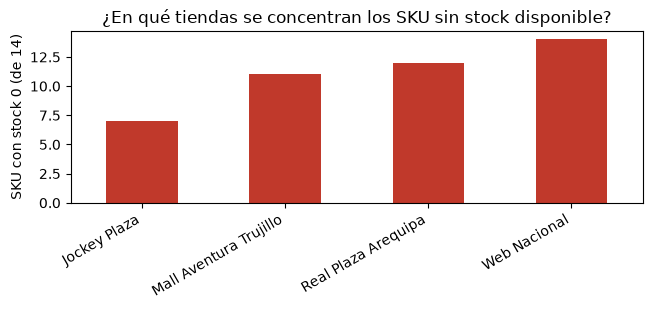

In [7]:
print(f"Stock al cierre ({cierre['Fecha'].iloc[0]}): sistema {sis_cierre} u. | "
      f"reservado {res_cierre} u. | disponible {disp_cierre} u.")
print(f"Combos SKU×tienda con disponible = 0: {combos_cero} de {len(cierre)} ({kpi_stock0_pct:.1f}%)")

c0_tienda = cierre.assign(cero=cierre["StockDisponible"].eq(0)).groupby("NombreTienda")["cero"].sum()
print("\nSKUs con stock 0 por tienda (de 14):")
display(c0_tienda.astype(int).rename("SKUs con stock 0").to_frame())

ax = c0_tienda.plot(kind="bar", color="#c0392b", figsize=(6.5, 3.2),
                    title="¿En qué tiendas se concentran los SKU sin stock disponible?")
ax.set_xlabel("")
ax.set_ylabel("SKU con stock 0 (de 14)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [8]:
print("Movimientos por alcance (los INGRESO y AJUSTE no tienen pedido):")
display(m["Alcance"].value_counts().rename("movimientos").to_frame())
print("Por tipo:")
display(m.groupby("TipoMovimiento").agg(movimientos=("MovimientoID", "size"), unidades=("Cantidad", "sum")))

print("Coherencia ledger vs. stock al cierre:")
print(f"  INGRESO+AJUSTE+DESCUENTO = {sis_mov} u. | StockSistema cierre = {sis_cierre} u.")
print(f"  RESERVA+LIBERACION+DESCUENTO = {res_mov} u. | StockReservado cierre = {res_cierre} u.")
print(f"  disponible = {sis_mov - res_mov} u. | StockDisponible cierre = {disp_cierre} u.")

Movimientos por alcance (los INGRESO y AJUSTE no tienen pedido):


,movimientos
Alcance,
Fase 4,86
Global (sin pedido),22
Heredado Fase 3,8


Por tipo:


,movimientos,unidades
TipoMovimiento,,
AJUSTE,9,7
DESCUENTO_DEFINITIVO,36,-57
INGRESO,13,97
LIBERACION_RESERVA,10,-12
RESERVA,48,71


Coherencia ledger vs. stock al cierre:
  INGRESO+AJUSTE+DESCUENTO = 47 u. | StockSistema cierre = 47 u.
  RESERVA+LIBERACION+DESCUENTO = 2 u. | StockReservado cierre = 2 u.
  disponible = 45 u. | StockDisponible cierre = 45 u.


## 6. Devoluciones

```
Tasa de devolución = devoluciones Fase 4 / líneas en estado "Completado" (entregadas) × 100
```

Las 6 devoluciones recaen sobre líneas entregadas (verificado abajo). Con `n = 6` el resultado
es descriptivo: se muestran también las variantes para que la elección del denominador sea
visible y no una caja negra.

In [9]:
j = d.merge(f4[["LineaID", "EstadoActual"]], on="LineaID", how="left")
print("Estado de la línea devuelta:", j["EstadoActual"].value_counts(dropna=False).to_dict())
print(f"\nTasa de devolución (principal): {kpi_tasa_dev:.1f}% = {len(d)} / {entregadas} líneas completadas × 100")
print(f"Variante por unidades: {100 * int(d['CantidadLinea'].sum()) / entregadas:.1f}% "
      f"({int(d['CantidadLinea'].sum())} u. / {entregadas})")
print(f"Variante sobre pedidos gestionados: {100 * len(d) / n_pedidos:.1f}% ({len(d)} / {n_pedidos})")

print("\nDesglose:")
display(d["NombreMotivo"].value_counts().rename("devoluciones").to_frame())
display(d["Categoria"].value_counts().rename("devoluciones").to_frame())
display(d["NombreTienda"].value_counts().rename("devoluciones").to_frame())

Estado de la línea devuelta: {'Completado': 6}

Tasa de devolución (principal): 19.4% = 6 / 31 líneas completadas × 100
Variante por unidades: 29.0% (9 u. / 31)
Variante sobre pedidos gestionados: 13.3% (6 / 45)

Desglose:


,devoluciones
NombreMotivo,
talla_incorrecta,2
producto_dañado,2
no_cumple_expectativa,2


,devoluciones
Categoria,
Ropa,4
Perfumería,1
Calzado,1


,devoluciones
NombreTienda,
Jockey Plaza,3
Real Plaza Arequipa,2
Mall Aventura Trujillo,1


## 7. Desgloses: fecha, tienda, canal, categoría

Los desgloses se calculan sobre el **mismo numerador/denominador** definido arriba; nada de
nuevos KPIs, solo el mismo corte desagregado.

In [10]:
por_mes = pd.DataFrame({
    "líneas": f4.groupby("Mes").size(),
    "canceladas": f4.loc[canceladas].groupby("Mes").size(),
    "incidencias": i4.groupby("Mes").size(),
    "devoluciones": d.groupby("Mes").size(),
}).fillna(0).astype(int)
por_mes["% cancelación"] = (100 * por_mes["canceladas"] / por_mes["líneas"]).round(1)
display(por_mes)

,líneas,canceladas,incidencias,devoluciones,% cancelación
Mes,,,,,
1,14,2,2,2,14.3
2,13,3,3,4,23.1
3,25,6,6,0,24.0


In [11]:
for col, etiqueta in [("NombreTienda", "tienda"), ("Canal", "canal"), ("Categoria", "categoría")]:
    ct = pd.crosstab(f4[col].fillna("(sin tienda: Rechazado)"), f4["EstadoActual"], margins=True)
    ct["% cancelación"] = (100 * ct.get("Cancelado", 0) / ct["All"]).round(1)
    print(f"Por {etiqueta}:")
    display(ct)

Por tienda:


EstadoActual,Cancelado,Completado,Incidencia de picking,Rechazado,All,% cancelación
NombreTienda,,,,,,
(sin tienda: Rechazado),0,0,0,8,8,0.0
Jockey Plaza,5,11,0,0,16,31.2
Mall Aventura Trujillo,3,8,1,0,12,25.0
Real Plaza Arequipa,3,12,1,0,16,18.8
All,11,31,2,8,52,21.2


Por canal:

EstadoActual,Cancelado,Completado,Incidencia de picking,Rechazado,All,% cancelación
Canal,,,,,,
despacho,5,12,0,4,21,23.8
recojo,6,19,2,4,31,19.4
All,11,31,2,8,52,21.2


Por categoría:


EstadoActual,Cancelado,Completado,Incidencia de picking,Rechazado,All,% cancelación
Categoria,,,,,,
Accesorios,1,4,1,1,7,14.3
Calzado,2,5,0,2,9,22.2
Perfumería,1,7,1,0,9,11.1
Ropa,7,15,0,5,27,25.9
All,11,31,2,8,52,21.2


## 8. Campaña vs. no campaña

Comparación **únicamente descriptiva** de las diferencias observadas. **No se afirma causalidad.**
La campaña (`Cyber Origen`, 2026-03-15 a 2026-03-21, 7 días) cae dentro de marzo, que ya
concentra el mayor volumen del trimestre (25 de 52 líneas): cualquier diferencia es un corte,
no un efecto aislado y medible de la campaña.

,Campaña,No campaña
Pedidos,9,36
Líneas,11,41
Líneas canceladas,5,6
% cancelación (líneas),45.5%,14.6%
Incidencias,3,8
Incidencias por 100 líneas,27.3,19.5
Incidencias no resueltas,0,6
Movimientos de inventario,24,92


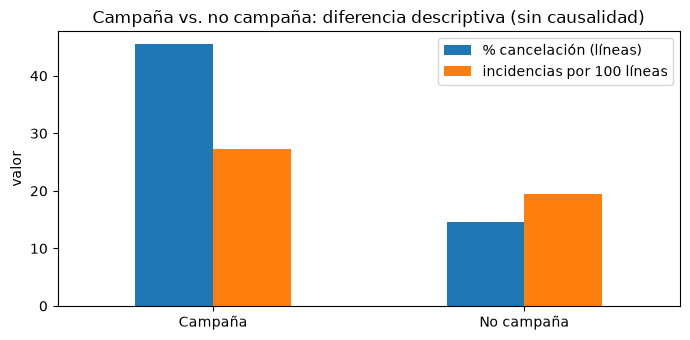

In [12]:
camp = set(p.loc[p["EsCampania"], "FechaID"].unique())
lc, ln = f4[f4["EsCampania"]], f4[~f4["EsCampania"]]
i4c, i4n = i4[i4["FechaID"].isin(camp)], i4[~i4["FechaID"].isin(camp)]
mc = int(m["FechaID"].isin(camp).sum())

comparativa = pd.DataFrame({
    "Campaña": [
        int(lc["PedidoID"].nunique()), len(lc), int(lc["EstadoActual"].eq("Cancelado").sum()),
        f"{100 * lc['EstadoActual'].eq('Cancelado').sum() / len(lc):.1f}%",
        len(i4c), f"{100 * len(i4c) / len(lc):.1f}",
        int(i4c["EstadoResolucion"].ne("resuelta").sum()), mc,
    ],
    "No campaña": [
        int(ln["PedidoID"].nunique()), len(ln), int(ln["EstadoActual"].eq("Cancelado").sum()),
        f"{100 * ln['EstadoActual'].eq('Cancelado').sum() / len(ln):.1f}%",
        len(i4n), f"{100 * len(i4n) / len(ln):.1f}",
        int(i4n["EstadoResolucion"].ne("resuelta").sum()), len(m) - mc,
    ],
}, index=["Pedidos", "Líneas", "Líneas canceladas", "% cancelación (líneas)",
          "Incidencias", "Incidencias por 100 líneas", "Incidencias no resueltas",
          "Movimientos de inventario"])
display(comparativa)

graf = pd.DataFrame({
    "% cancelación (líneas)": [
        100 * lc["EstadoActual"].eq("Cancelado").sum() / len(lc),
        100 * ln["EstadoActual"].eq("Cancelado").sum() / len(ln),
    ],
    "incidencias por 100 líneas": [100 * len(i4c) / len(lc), 100 * len(i4n) / len(ln)],
}, index=["Campaña", "No campaña"])
ax = graf.plot(kind="bar", figsize=(7, 3.5),
               title="Campaña vs. no campaña: diferencia descriptiva (sin causalidad)")
ax.set_ylabel("valor")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. SLA — no definido

**El proyecto no contiene una meta SLA formal, por lo que no se calcula ningún cumplimiento:**

- `docs/01_procesos_y_reglas.md` §10 lista el parámetro *"SLA objetivo (por etapa del pedido)"*
  entre los parámetros **sin valor concreto** (RN-030: nada va hardcodeado).
- `sql/06_views/` lo declara explícito: las vistas *"no implementan SLA, ni niveles, ni
  ventanas, ni criticidad; solo miden duraciones"*.
- En consecuencia, la pregunta de `docs/00` §7 *"¿Qué proporción de pedidos incumple el SLA?"*
  **no es contestable todavía** y queda pendiente de que se defina la meta.

Lo que sí se conserva para análisis posterior: los tiempos operativos de `vw_TiemposEstados`
(episodios y duraciones), mostrados abajo solo como insumo futuro.

In [13]:
tiempos = pd.DataFrame({
    "episodios": t4["NombreEstado"].value_counts(),
    "con duración": t4.groupby("NombreEstado")["DuracionMinutos"].count(),
    "mediana (min)": t4.groupby("NombreEstado")["DuracionMinutos"].median(),
    "máximo (min)": t4.groupby("NombreEstado")["DuracionMinutos"].max(),
})
display(tiempos.round(1))

dur = t4["DuracionMinutos"].dropna()
print(f"Episodios Fase 4: {len(t4)} | con duración medida: {len(dur)} | con duración > 0: {int((dur > 0).sum())}")
print(f"Mediana: {dur.median():.0f} min | máximo: {dur.max():.0f} min (≈ {dur.max() / 1440:.1f} días)")
print("Sin meta SLA definida → NO se calcula 'cumplimiento SLA'.")

,episodios,con duración,mediana (min),máximo (min)
NombreEstado,,,,
Asignado a picking,42,42,0.0,0.0
Cancelado,11,0,NaN,NaN
Completado,31,0,NaN,NaN
Disponible para recojo,21,21,0.0,5004.0
Empaquetado,33,33,0.0,0.0
En tránsito,12,12,0.0,0.0
Entregado,12,12,0.0,0.0
Incidencia de picking,9,7,5004.0,5004.0
Pedido creado,44,44,0.0,0.0


Episodios Fase 4: 288 | con duración medida: 236 | con duración > 0: 6
Mediana: 0 min | máximo: 5004 min (≈ 3.5 días)
Sin meta SLA definida → NO se calcula 'cumplimiento SLA'.


## 10. Limitaciones

1. **No hay precios ni montos** en ningún CSV → ningún KPI financiero (ventas, GMV, margen).
2. **No existe stock físico por tienda** → no se mide brecha sistema vs. físico.
3. **No existe meta SLA formal** → no hay cumplimiento SLA (sección 9).
4. **Dataset pequeño:** 45 pedidos, 52 líneas, 11 incidencias, 6 devoluciones, 90 días;
   las tasas son frágiles (una línea mueve ~2 pp la cancelación).
5. **`stock_historico` no está vinculado a pedidos** → sus KPIs usan alcance completo y no se
   desglosan por canal/campaña de pedidos.
6. **Los movimientos globales no tienen `PedidoID`** (22 de 116: configuración inicial,
   recepciones CD y ajustes) → su análisis es por tipo/origen/fecha, nunca por pedido.
7. **El estado es atributo de línea** → la tasa de cancelación principal es de líneas; las
   variantes por pedido se muestran aparte (24,4% / 17,8%).
8. **`TipoIncidencia` y `NombreMotivo` coinciden** 1:1 en este dataset → son una sola
   dimensión de práctica, no dos evidencias independientes.
9. **Dos relojes temporales** (fecha de negocio 2026-01-01…03-31 vs. ejecución real
   2026-09-29…10-05) → toda serie temporal usa `FechaID`.
10. **No se crea `data/processed/`:** los resultados de este notebook son reproducibles
    directo desde `data/raw/`; si Power BI necesita extractos derivados, se definirá y
    documentará en su propia fase (por qué, qué columnas y qué reglas), no por inercia.

---
*Fin del Paso 3 (definición de KPIs). Power BI y hallazgos quedan para las siguientes etapas.*